In [16]:
import pandas as pd
import numpy as np

df = pd.read_csv("hr_attrition_dataset_100k.csv")
df.head()

,employee_id,age,gender,department,job_role,education_field,salary,years_at_company,job_satisfaction,work_life_balance,training_hours,performance_rating,distance_from_home_km,overtime,attrition
0,100000,59,Female,Marketing,HR Manager,Medical,57912.0,35,3.0,1.0,58.0,2,9,No,No
1,100001,49,Other,Sales,Accountant,Medical,76384.0,16,1.0,1.0,17.0,2,30,no,No
2,100002,35,Other,Marketing,Operations Manager,Life Sciences,68578.0,35,4.0,1.0,55.0,1,48,no,No
3,100003,28,Female,Human Resources,Accountant,Technical Degree,81456.0,18,2.0,2.0,9.0,4,28,yes,Yes
4,100004,41,Male,Sales,Operations Manager,Technical Degree,84070.0,3,1.0,3.0,54.0,2,7,yes,No


In [17]:
"""df.shape"""
"""df.columns"""
"""df.info"""
df.describe()

,employee_id,age,salary,years_at_company,job_satisfaction,work_life_balance,training_hours,performance_rating,distance_from_home_km
count,102000.000000,102000.000000,98943.000000,102000.000000,98939.000000,98944.000000,98939.000000,102000.000000,102000.000000
mean,149989.803598,40.066147,65013.444124,19.511853,2.498054,2.496988,39.440362,2.504343,24.898265
std,28864.986883,11.245854,20023.927247,11.547114,1.117002,1.121069,23.106203,1.118399,14.148836
min,100000.000000,21.000000,-20027.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000
25%,124991.750000,30.000000,51520.000000,9.000000,1.000000,1.000000,19.000000,2.000000,13.000000
50%,149969.500000,40.000000,65028.000000,20.000000,2.000000,2.000000,39.000000,3.000000,25.000000
75%,174987.250000,50.000000,78490.000000,30.000000,3.000000,4.000000,59.000000,4.000000,37.000000
max,199999.000000,59.000000,143363.000000,39.000000,4.000000,4.000000,79.000000,4.000000,49.000000


In [18]:
df.isnull().sum()

employee_id                 0
age                         0
gender                      0
department                  0
job_role                    0
education_field             0
salary                   3057
years_at_company            0
job_satisfaction         3061
work_life_balance        3056
training_hours           3061
performance_rating          0
distance_from_home_km       0
overtime                    0
attrition                   0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(2000)

In [20]:
"""delet all duplicates"""
df.drop_duplicates(inplace=True)

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
"""Handling Null Values"""

df['salary'] = df['salary'].fillna(df['salary'].mean())

df['job_satisfaction'] = df['job_satisfaction'].fillna(df['job_satisfaction'].mean())

df['work_life_balance'] = df['work_life_balance'].fillna(df['work_life_balance'].mean())

df['training_hours'] = df['training_hours'].fillna(df['training_hours'].mean())

df.isnull().sum()

employee_id              0
age                      0
gender                   0
department               0
job_role                 0
education_field          0
salary                   0
years_at_company         0
job_satisfaction         0
work_life_balance        0
training_hours           0
performance_rating       0
distance_from_home_km    0
overtime                 0
attrition                0
dtype: int64

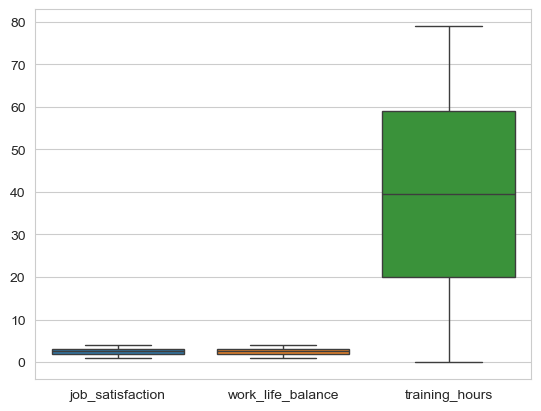

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df[['job_satisfaction','work_life_balance','training_hours']])
plt.show()

In [78]:
"""df[['job_satisfaction','work_life_balance','training_hours']].describe()"""

Q1 = df['training_hours'].quantile(0.25)
Q3 = df['training_hours'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['training_hours'] = df['training_hours'].clip(lower, upper)



In [25]:
columns = ['job_satisfaction','work_life_balance','training_hours']

for col in columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower, upper)

    

In [26]:

df['job_satisfaction'].max()
df['work_life_balance'].max()
df['training_hours'].max()

79.0

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

clean_df = pd.read_csv("clean_hr_attrition_dataset_16.csv")
clean_df.head()

,employee_id,age,gender,department,job_role,education_field,salary,years_at_company,job_satisfaction,work_life_balance,training_hours,performance_rating,distance_from_home_km,overtime,attrition
0,100000,59,Female,Marketing,HR Manager,Medical,57912.0,35,3,1,58,2,9,No,No
1,100001,49,Other,Sales,Accountant,Medical,76384.0,16,1,1,17,2,30,no,No
2,100002,35,Other,Marketing,Operations Manager,Life Sciences,68578.0,35,4,1,55,1,48,no,No
3,100003,28,Female,Human Resources,Accountant,Technical Degree,81456.0,18,2,2,9,4,28,yes,Yes
4,100004,41,Male,Sales,Operations Manager,Technical Degree,84070.0,3,1,3,54,2,7,yes,No


In [28]:
clean_df.describe()

,employee_id,age,salary,years_at_company,job_satisfaction,work_life_balance,training_hours,performance_rating,distance_from_home_km
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,149999.500000,40.058210,65017.209757,19.511980,2.483010,2.48149,39.427950,2.503590,24.902260
std,28867.657797,11.243079,19704.500889,11.549876,1.103668,1.10700,22.766984,1.118302,14.147517
min,100000.000000,21.000000,35.000000,0.000000,1.000000,1.00000,0.000000,1.000000,1.000000
25%,124999.750000,30.000000,51985.750000,9.000000,2.000000,2.00000,20.000000,2.000000,13.000000
50%,149999.500000,40.000000,65010.888580,20.000000,2.000000,2.00000,39.000000,3.000000,25.000000
75%,174999.250000,50.000000,78006.250000,30.000000,3.000000,3.00000,59.000000,4.000000,37.000000
max,199999.000000,59.000000,143363.000000,39.000000,4.000000,4.00000,79.000000,4.000000,49.000000


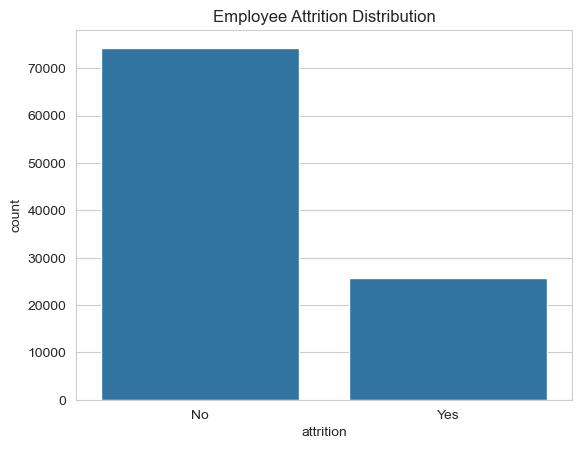

In [29]:
sns.countplot(x="attrition", data=clean_df)
plt.title("Employee Attrition Distribution")
plt.show()

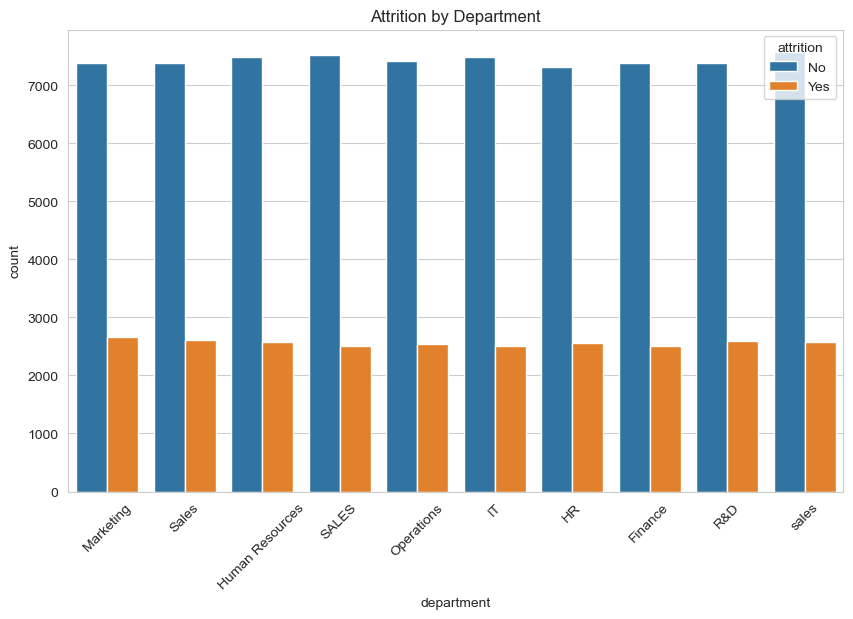

In [30]:
plt.figure(figsize=(10,6))
sns.countplot(x="department", hue="attrition", data=clean_df)
plt.title("Attrition by Department")
plt.xticks(rotation=45)
plt.show()

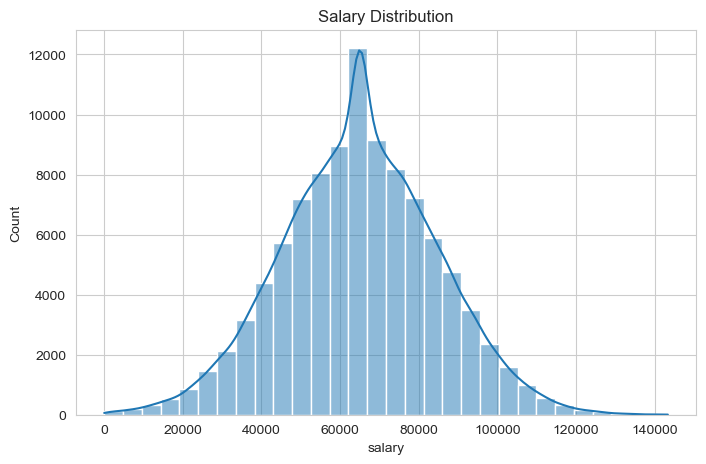

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(clean_df["salary"], bins=30, kde=True)

plt.title("Salary Distribution")

plt.show()

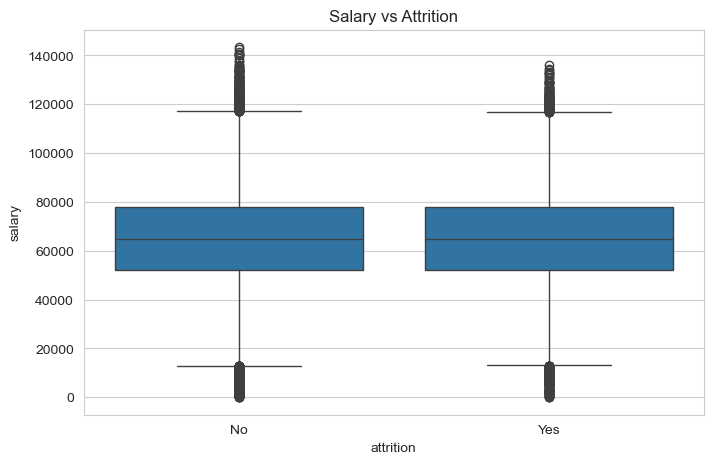

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(x="attrition", y="salary", data=clean_df)

plt.title("Salary vs Attrition")

plt.show()

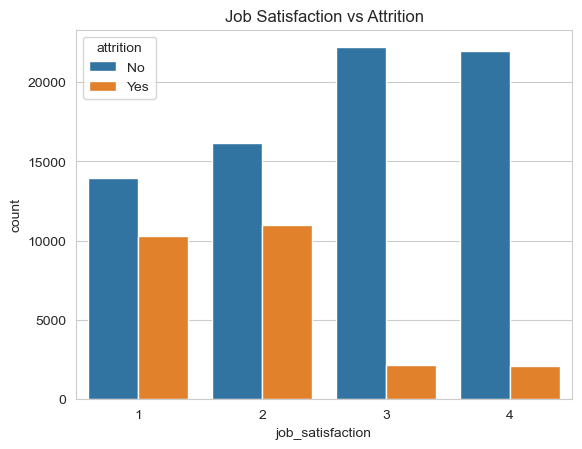

In [33]:
sns.countplot(x="job_satisfaction", hue="attrition", data=clean_df)

plt.title("Job Satisfaction vs Attrition")

plt.show()

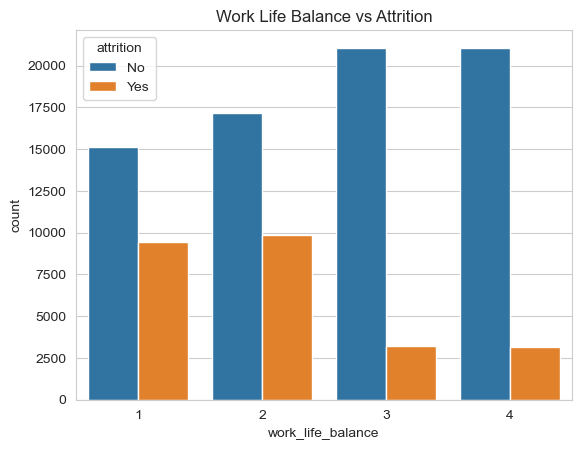

In [34]:
sns.countplot(x="work_life_balance", hue="attrition", data=clean_df)

plt.title("Work Life Balance vs Attrition")

plt.show()

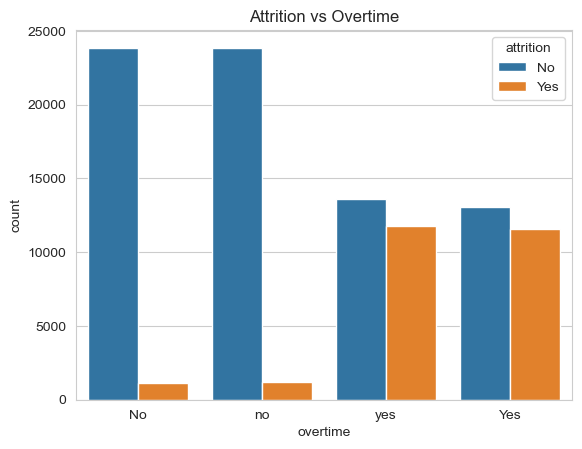

In [35]:
sns.countplot(x='overtime', hue='attrition', data=clean_df)

plt.title("Attrition vs Overtime")

plt.show()

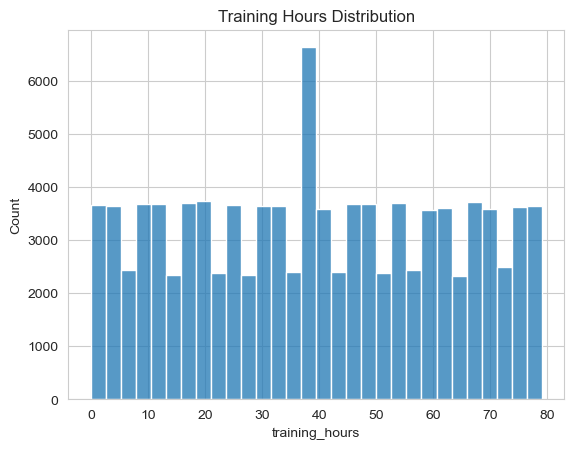

In [36]:
sns.histplot(clean_df["training_hours"], bins=30)

plt.title("Training Hours Distribution")

plt.show()

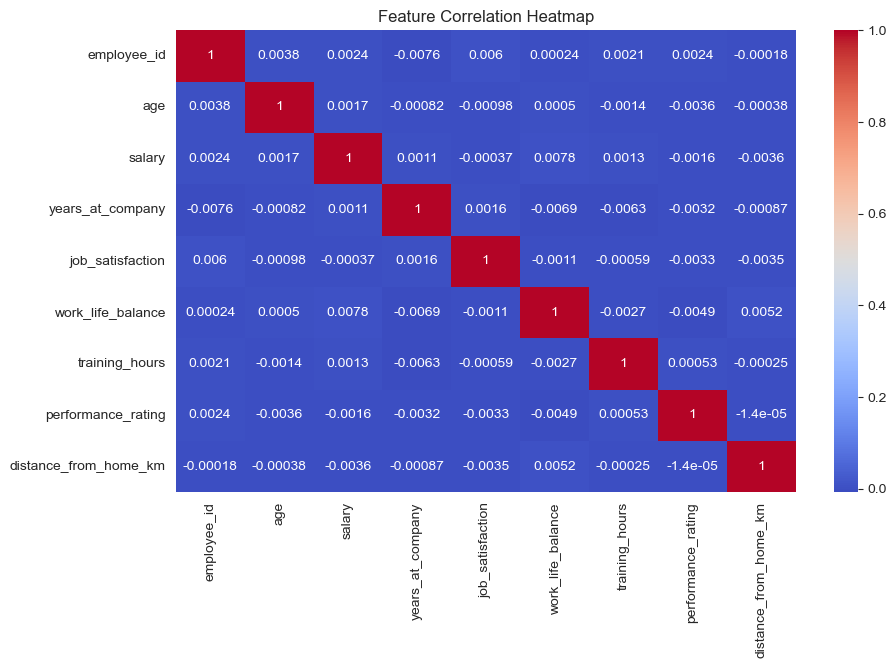

In [37]:
plt.figure(figsize=(10,6))

sns.heatmap(clean_df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

In [38]:
clean_df.describe()


,employee_id,age,salary,years_at_company,job_satisfaction,work_life_balance,training_hours,performance_rating,distance_from_home_km
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,149999.500000,40.058210,65017.209757,19.511980,2.483010,2.48149,39.427950,2.503590,24.902260
std,28867.657797,11.243079,19704.500889,11.549876,1.103668,1.10700,22.766984,1.118302,14.147517
min,100000.000000,21.000000,35.000000,0.000000,1.000000,1.00000,0.000000,1.000000,1.000000
25%,124999.750000,30.000000,51985.750000,9.000000,2.000000,2.00000,20.000000,2.000000,13.000000
50%,149999.500000,40.000000,65010.888580,20.000000,2.000000,2.00000,39.000000,3.000000,25.000000
75%,174999.250000,50.000000,78006.250000,30.000000,3.000000,3.00000,59.000000,4.000000,37.000000
max,199999.000000,59.000000,143363.000000,39.000000,4.000000,4.00000,79.000000,4.000000,49.000000


In [39]:
"""ML"""
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

clean_df['gender'] = le.fit_transform(clean_df['gender'])
clean_df['department'] = le.fit_transform(clean_df['department'])
clean_df['job_role'] = le.fit_transform(clean_df['job_role'])
clean_df['education_field'] = le.fit_transform(clean_df['education_field'])

In [40]:
clean_df['attrition'] = clean_df['attrition'].map({'Yes':1, 'No':0})
"""(change char(txt) to numerical) now yes = 1 and no = 0"""

'(change char(txt) to numerical) now yes = 1 and no = 0'

In [41]:
clean_df['overtime'] = clean_df['overtime'].map({'yes':1, 'no':0})

In [42]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   employee_id            100000 non-null  int64  
 1   age                    100000 non-null  int64  
 2   gender                 100000 non-null  int64  
 3   department             100000 non-null  int64  
 4   job_role               100000 non-null  int64  
 5   education_field        100000 non-null  int64  
 6   salary                 100000 non-null  float64
 7   years_at_company       100000 non-null  int64  
 8   job_satisfaction       100000 non-null  int64  
 9   work_life_balance      100000 non-null  int64  
 10  training_hours         100000 non-null  int64  
 11  performance_rating     100000 non-null  int64  
 12  distance_from_home_km  100000 non-null  int64  
 13  overtime               50366 non-null   float64
 14  attrition              100000 non-nul

In [43]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [44]:
"""X = input features y = prediction target"""
clean_df = clean_df.drop('employee_id', axis=1)


In [45]:
X = clean_df.drop('attrition', axis=1)
y = clean_df['attrition']

In [46]:
"""train model"""
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [47]:
clean_df.isnull().sum()

age                          0
gender                       0
department                   0
job_role                     0
education_field              0
salary                       0
years_at_company             0
job_satisfaction             0
work_life_balance            0
training_hours               0
performance_rating           0
distance_from_home_km        0
overtime                 49634
attrition                    0
dtype: int64

In [48]:
clean_df['overtime'] = clean_df['overtime'].fillna(clean_df['overtime'].mode()[0])

In [49]:
"""model.fit(X_train, y_train)"""
clean_df.isnull().sum()

age                      0
gender                   0
department               0
job_role                 0
education_field          0
salary                   0
years_at_company         0
job_satisfaction         0
work_life_balance        0
training_hours           0
performance_rating       0
distance_from_home_km    0
overtime                 0
attrition                0
dtype: int64

In [50]:
X.isnull().sum()

age                          0
gender                       0
department                   0
job_role                     0
education_field              0
salary                       0
years_at_company             0
job_satisfaction             0
work_life_balance            0
training_hours               0
performance_rating           0
distance_from_home_km        0
overtime                 49634
dtype: int64

In [51]:
X_train.isnull().sum()

age                          0
gender                       0
department                   0
job_role                     0
education_field              0
salary                       0
years_at_company             0
job_satisfaction             0
work_life_balance            0
training_hours               0
performance_rating           0
distance_from_home_km        0
overtime                 39665
dtype: int64

In [52]:
X = clean_df.drop('attrition', axis=1)
y = clean_df['attrition']

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [55]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=3000, solver='lbfgs')
model.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

In [56]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7958


In [57]:
"""models"""

'models'

In [58]:
"""1. Decision tree"""
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)

In [59]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [60]:
y_pred_dt = dt_model.predict(X_test)

In [61]:
from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7456


In [62]:
"""2. random forest"""
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [63]:
"""100 trees → each makes prediction Final prediction → majority vote"""

'100 trees → each makes prediction Final prediction → majority vote'

In [64]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [65]:
y_pred_rf = rf_model.predict(X_test)

In [66]:
from sklearn.metrics import accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.8227


In [67]:
"""feature importance"""
import pandas as pd

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

                  Feature  Importance
7        job_satisfaction    0.160776
5                  salary    0.106670
8       work_life_balance    0.100139
12               overtime    0.094490
9          training_hours    0.090273
6        years_at_company    0.083941
11  distance_from_home_km    0.083429
0                     age    0.081504
2              department    0.052774
3                job_role    0.048325
4         education_field    0.041370
10     performance_rating    0.032161
1                  gender    0.024149


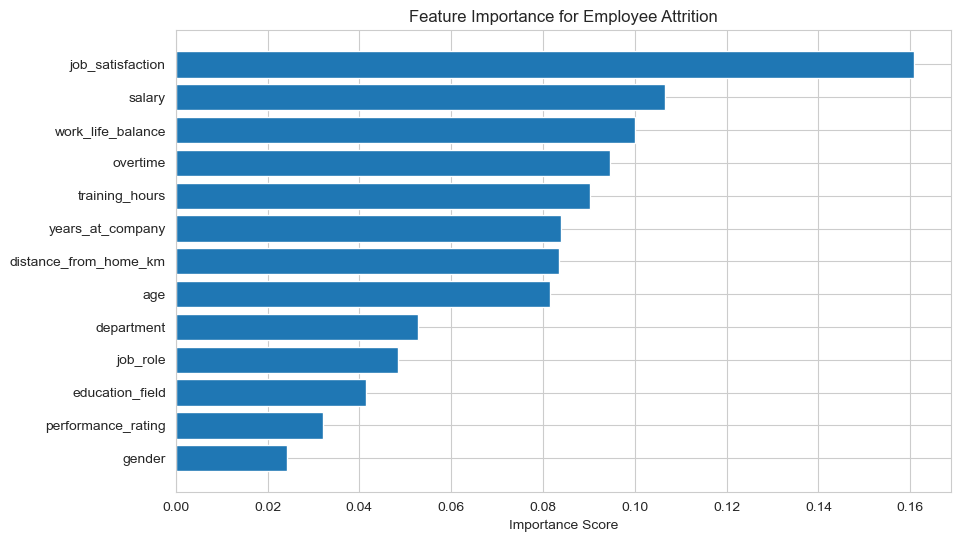

In [68]:
"""why emp leave"""
import matplotlib.pyplot as plt
import pandas as pd

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance for Employee Attrition")
plt.xlabel("Importance Score")
plt.show()

In [69]:
"""confusion matrix"""
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[13626  1251]
 [ 2295  2828]]


In [70]:
"""13k = stayed employee correct prediction, 1242= stayed but pridiction is leaving
   2299 = predic is stay but left , 2824 =left correct pred  """

'13k = stayed employee correct prediction, 1242= stayed but pridiction is leaving\n   2299 = predic is stay but left , 2824 =left correct pred  '

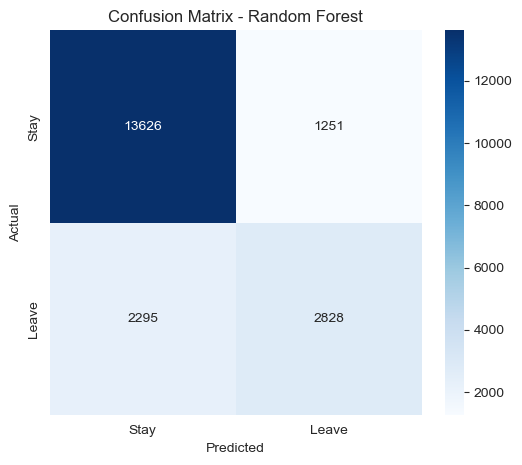

In [71]:
"""visual"""
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Stay','Leave'],
            yticklabels=['Stay','Leave'])

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [72]:
"""PREDICTION SYSTEM"""

import pandas as pd

new_employee = pd.DataFrame([{
    'age': 35,
    'gender': 1,
    'department': 2,
    'job_role': 3,
    'education_field': 1,
    'salary': 50000,
    'years_at_company': 5,
    'job_satisfaction': 2,
    'work_life_balance': 3,
    'training_hours': 20,
    'performance_rating': 3,
    'distance_from_home_km': 10,
    'overtime': 1
}])
prediction = rf_model.predict(new_employee.values)

print(prediction)

if prediction[0] == 1:
    print("Prediction: Employee Likely To Leave")
else:
    print("Prediction: Employee Likely To Stay")

[0]
Prediction: Employee Likely To Stay


In [73]:
"""ROC curve"""
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
y_prob = rf_model.predict_proba(X_test)[:,1]

In [74]:
"""FPR = False Positive Rate ,TPR = True Positive Rate ,thresholds = decision boundaries"""
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [75]:
auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

AUC Score: 0.8623752443273177


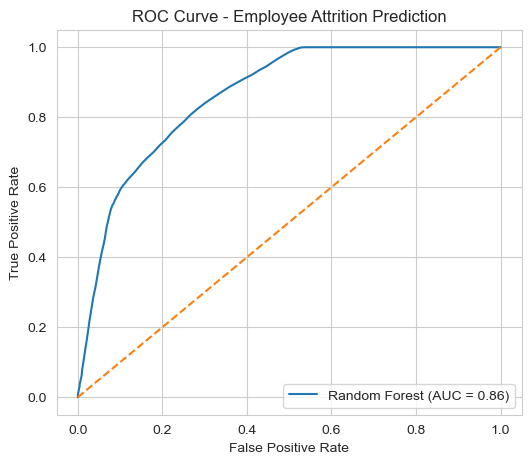

In [76]:
"""curve"""
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="Random Forest (AUC = %.2f)" % auc_score)

plt.plot([0,1],[0,1],'--')  # random prediction line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Employee Attrition Prediction")
plt.legend()

plt.show()